# Results Analysis

Comprehensive analysis of **ResNet18**, **MobileNetV2**, and **AST** experiments for speech classification.  
Data source: `reports/visualizations/results_summary.csv` (generated by `_collect_results.py`).

---


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from pathlib import Path

sns.set_theme(style="whitegrid", palette="tab10")
plt.rcParams.update({"figure.dpi": 120, "figure.facecolor": "white", "font.size": 11})

CSV = Path("visualizations/results_summary.csv")
df = pd.read_csv(CSV)

# Coerce numeric columns
num_cols = [c for c in df.columns if c not in ("Experiment", "Architecture", "Model Name",
            "Seed List", "Device", "Device Name", "Optimizer", "Balancing",
            "SpecAugment", "Freeze Backbone", "Use Pretrained")]
df[num_cols] = df[num_cols].apply(pd.to_numeric, errors="coerce")

# Short label for plots
df["Label"] = (df["Experiment"]
    .str.replace("resnet18_full_", "", regex=False)
    .str.replace("resnet18_", "", regex=False)
    .str.replace("mobilenetv2_full_", "mv2_", regex=False)
    .str.replace("ast_full_", "ast_", regex=False))

print(f"Loaded {len(df)} experiments, {len(df.columns)} columns")
df[["Experiment", "Architecture", "Seeds", "Test Acc Mean", "Test F1 Mean",
    "Train Time Mean (min)", "Inference Latency Mean (ms)"]].sort_values("Test Acc Mean", ascending=False)


Loaded 19 experiments, 58 columns


,Experiment,Architecture,Seeds,Test Acc Mean,Test F1 Mean,Train Time Mean (min),Inference Latency Mean (ms)
8,resnet18_full_specaugment,resnet18,4,97.9078,96.8742,61.1834,1.0349
6,mobilenetv2_full_specaugment,mobilenetv2,4,97.6481,96.3670,109.3695,1.5184
9,resnet18_full_optimizer_sgd,resnet18,4,97.5713,96.2306,75.3528,0.6017
10,resnet18_full_dropout_p05,resnet18,3,97.4494,96.0705,93.7536,1.1408
11,resnet18_full_lr0003,resnet18,4,97.4433,95.9814,61.6158,0.8436
18,resnet18_full_baseline_no_audio_tweaks,resnet18_no_audio_tweaks,4,97.2787,95.8013,47.3179,0.4270
0,ast_full_dropout_p03,AST,4,97.2751,87.8561,339.6535,6.0982
7,mobilenetv2_full_baseline,mobilenetv2,4,97.2641,95.8190,62.9743,1.1088
12,resnet18_full_baseline,resnet18,4,97.2092,95.6768,24.7755,0.4596
1,ast_full_baseline,AST,4,97.1836,87.6794,312.4628,6.0888


## 1. Architecture Comparison — Best per architecture


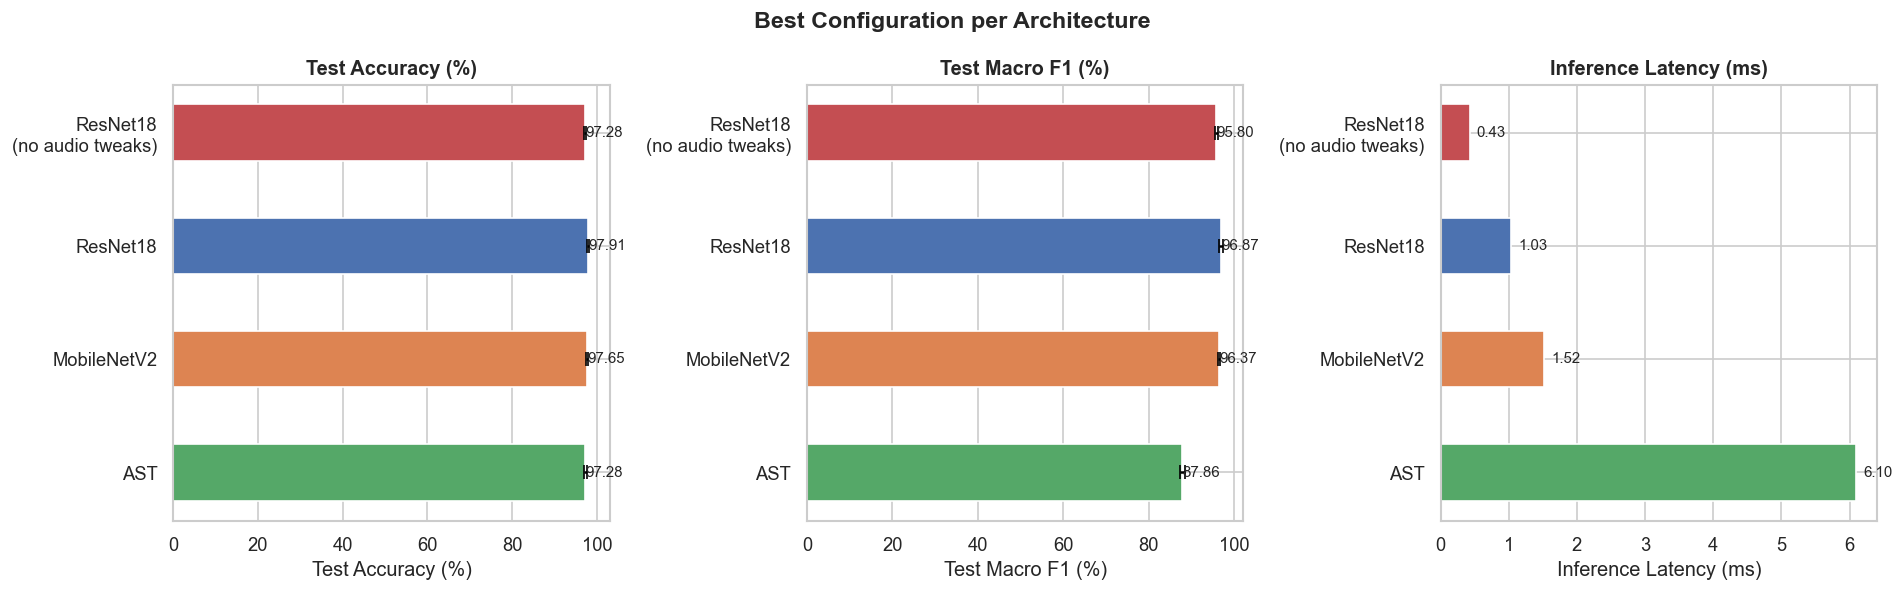

In [2]:
arch_order = ["resnet18", "mobilenetv2", "AST", "resnet18_no_audio_tweaks"]
arch_labels = {"resnet18": "ResNet18", "mobilenetv2": "MobileNetV2",
               "AST": "AST", "resnet18_no_audio_tweaks": "ResNet18\n(no audio tweaks)"}
palette = {"resnet18": "#4C72B0", "mobilenetv2": "#DD8452", "AST": "#55A868",
           "resnet18_no_audio_tweaks": "#C44E52"}

# Best experiment per architecture (highest Test Acc Mean)
best = df.loc[df.groupby("Architecture")["Test Acc Mean"].idxmax()].copy()
best["Arch Label"] = best["Architecture"].map(arch_labels)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metrics = [("Test Acc Mean", "Test Acc Std", "Test Accuracy (%)"),
           ("Test F1 Mean",  "Test F1 Std",  "Test Macro F1 (%)"),
           ("Inference Latency Mean (ms)", None, "Inference Latency (ms)")]

for ax, (col, err_col, title) in zip(axes, metrics):
    colors = [palette.get(a, "grey") for a in best["Architecture"]]
    xerr = best[err_col].values if err_col else None
    bars = ax.barh(best["Arch Label"], best[col], xerr=xerr,
                   color=colors, edgecolor="white", height=0.5, capsize=4)
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel(title)
    for bar, val in zip(bars, best[col]):
        ax.text(bar.get_width() + (0.1 if col == "Inference Latency Mean (ms)" else 0.05),
                bar.get_y() + bar.get_height() / 2,
                f"{val:.2f}", va="center", fontsize=9)

plt.suptitle("Best Configuration per Architecture", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("visualizations/arch_comparison_best.png", bbox_inches="tight")
plt.show()


## 2. ResNet18 Ablation Study


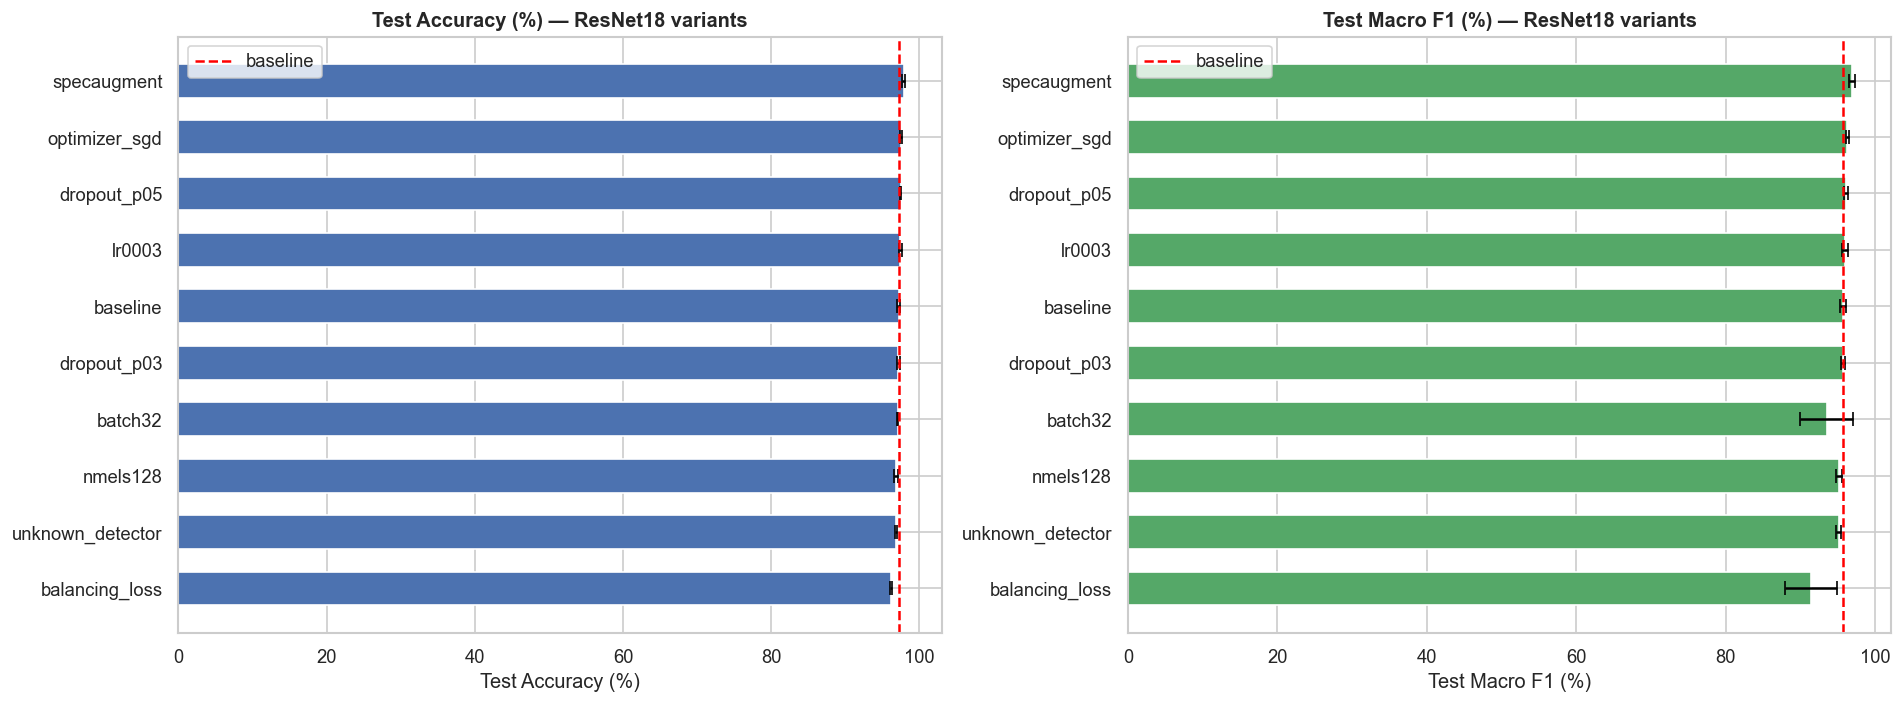

In [3]:
r18 = df[df["Architecture"] == "resnet18"].sort_values("Test Acc Mean", ascending=True).copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Accuracy with error bars
axes[0].barh(r18["Label"], r18["Test Acc Mean"], xerr=r18["Test Acc Std"],
             color="#4C72B0", edgecolor="white", capsize=4, height=0.6)
axes[0].axvline(r18[r18["Label"] == "baseline"]["Test Acc Mean"].values[0],
                color="red", linestyle="--", linewidth=1.5, label="baseline")
axes[0].set_title("Test Accuracy (%) — ResNet18 variants", fontweight="bold")
axes[0].set_xlabel("Test Accuracy (%)")
axes[0].legend()

# F1
axes[1].barh(r18["Label"], r18["Test F1 Mean"], xerr=r18["Test F1 Std"],
             color="#55A868", edgecolor="white", capsize=4, height=0.6)
axes[1].axvline(r18[r18["Label"] == "baseline"]["Test F1 Mean"].values[0],
                color="red", linestyle="--", linewidth=1.5, label="baseline")
axes[1].set_title("Test Macro F1 (%) — ResNet18 variants", fontweight="bold")
axes[1].set_xlabel("Test Macro F1 (%)")
axes[1].legend()

plt.tight_layout()
plt.savefig("visualizations/resnet18_ablation.png", bbox_inches="tight")
plt.show()


## 3. AST Ablation Study


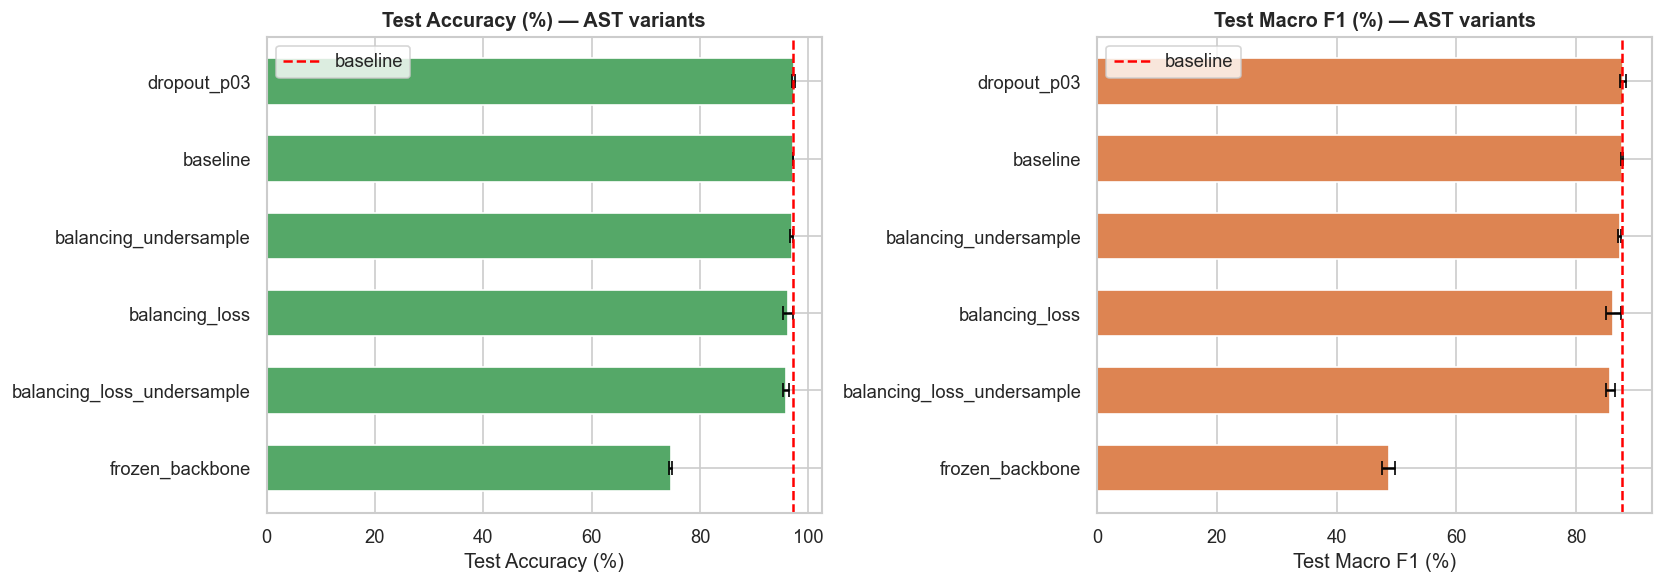

In [4]:
ast = df[df["Architecture"] == "AST"].sort_values("Test Acc Mean", ascending=True).copy()
ast["Label"] = ast["Experiment"].str.replace("ast_full_", "", regex=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(ast["Label"], ast["Test Acc Mean"], xerr=ast["Test Acc Std"],
             color="#55A868", edgecolor="white", capsize=4, height=0.6)
axes[0].axvline(ast[ast["Label"] == "baseline"]["Test Acc Mean"].values[0],
                color="red", linestyle="--", linewidth=1.5, label="baseline")
axes[0].set_title("Test Accuracy (%) — AST variants", fontweight="bold")
axes[0].set_xlabel("Test Accuracy (%)")
axes[0].legend()

axes[1].barh(ast["Label"], ast["Test F1 Mean"], xerr=ast["Test F1 Std"],
             color="#DD8452", edgecolor="white", capsize=4, height=0.6)
axes[1].axvline(ast[ast["Label"] == "baseline"]["Test F1 Mean"].values[0],
                color="red", linestyle="--", linewidth=1.5, label="baseline")
axes[1].set_title("Test Macro F1 (%) — AST variants", fontweight="bold")
axes[1].set_xlabel("Test Macro F1 (%)")
axes[1].legend()

plt.tight_layout()
plt.savefig("visualizations/ast_ablation.png", bbox_inches="tight")
plt.show()


## 4. Efficiency Frontier — Accuracy vs Training Time vs Latency


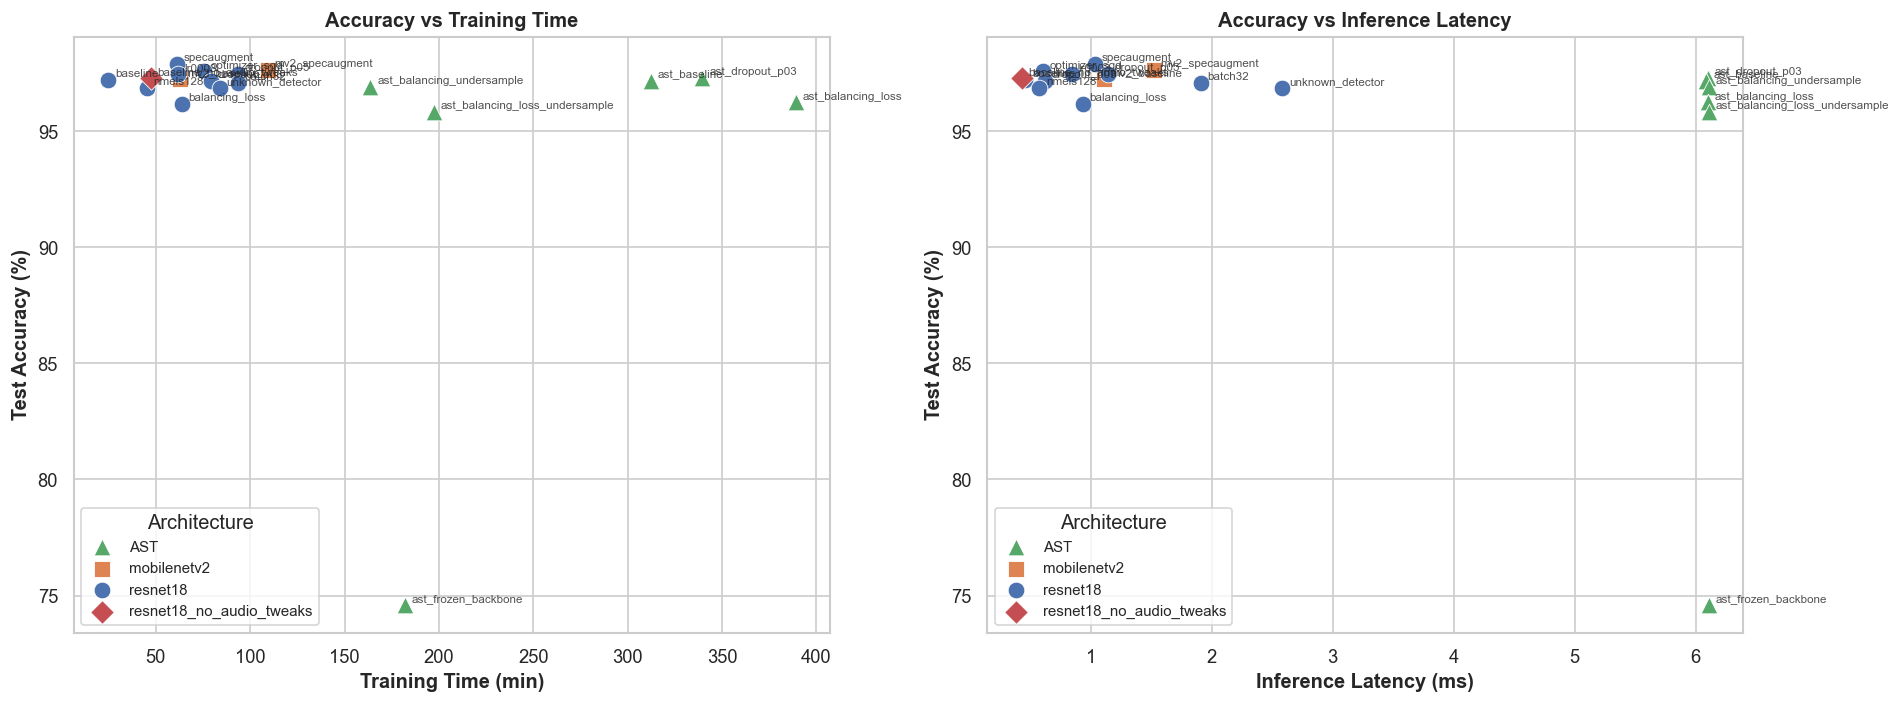

In [5]:
palette_arch = {"resnet18": "#4C72B0", "mobilenetv2": "#DD8452",
                "AST": "#55A868", "resnet18_no_audio_tweaks": "#C44E52"}
markers_arch = {"resnet18": "o", "mobilenetv2": "s", "AST": "^", "resnet18_no_audio_tweaks": "D"}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for arch, grp in df.groupby("Architecture"):
    color = palette_arch.get(arch, "grey")
    marker = markers_arch.get(arch, "o")
    axes[0].scatter(grp["Train Time Mean (min)"], grp["Test Acc Mean"],
                    c=color, marker=marker, s=100, label=arch, edgecolors="white", linewidths=0.5)
    axes[1].scatter(grp["Inference Latency Mean (ms)"], grp["Test Acc Mean"],
                    c=color, marker=marker, s=100, label=arch, edgecolors="white", linewidths=0.5)

# Annotate points
for _, row in df.iterrows():
    axes[0].annotate(row["Label"], (row["Train Time Mean (min)"], row["Test Acc Mean"]),
                     textcoords="offset points", xytext=(4, 2), fontsize=7, alpha=0.8)
    axes[1].annotate(row["Label"], (row["Inference Latency Mean (ms)"], row["Test Acc Mean"]),
                     textcoords="offset points", xytext=(4, 2), fontsize=7, alpha=0.8)

for ax, xlabel in zip(axes, ["Training Time (min)", "Inference Latency (ms)"]):
    ax.set_xlabel(xlabel, fontweight="bold")
    ax.set_ylabel("Test Accuracy (%)", fontweight="bold")
    ax.legend(title="Architecture", fontsize=9)

axes[0].set_title("Accuracy vs Training Time", fontweight="bold")
axes[1].set_title("Accuracy vs Inference Latency", fontweight="bold")

plt.tight_layout()
plt.savefig("visualizations/efficiency_frontier_new.png", bbox_inches="tight")
plt.show()


## 5. No-Override Evaluation (ResNet18) — with vs without Silence
Comparison of the standard test (with silence override) vs official evaluation modes.


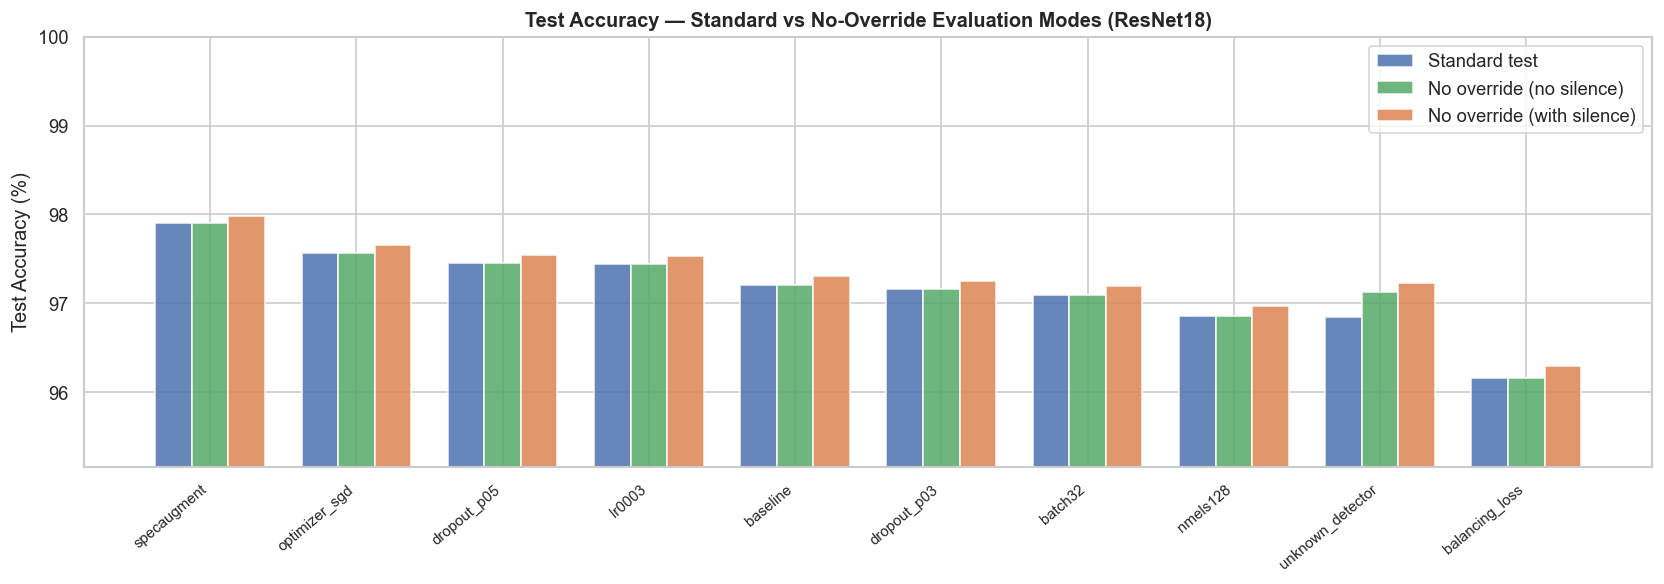

,Label,Test Acc Mean,No Ov Test Acc Mean,No Ov Sil Test Acc Mean,Δ no-sil,Δ with-sil
8,specaugment,97.9078,97.9078,97.9817,0.000,0.074
9,optimizer_sgd,97.5713,97.5713,97.6535,0.000,0.082
10,dropout_p05,97.4494,97.4494,97.5394,0.000,0.090
11,lr0003,97.4433,97.4433,97.5335,0.000,0.090
12,baseline,97.2092,97.2092,97.3077,0.000,0.099
13,dropout_p03,97.1617,97.1617,97.2512,0.000,0.090
14,batch32,97.0958,97.0958,97.1912,0.000,0.095
15,nmels128,96.8581,96.8581,96.9689,0.000,0.111
17,balancing_loss,96.1668,96.1668,96.3020,0.000,0.135
16,unknown_detector,96.8471,97.1251,97.2265,0.278,0.379


In [6]:
no_ov = df[df["No Ov Test Acc Mean"].notna()].copy()
no_ov["Label"] = no_ov["Experiment"].str.replace("resnet18_full_", "", regex=False)

x = np.arange(len(no_ov))
w = 0.25
fig, ax = plt.subplots(figsize=(14, 5))

ax.bar(x - w, no_ov["Test Acc Mean"], w, label="Standard test", color="#4C72B0", alpha=0.85)
ax.bar(x,     no_ov["No Ov Test Acc Mean"], w, label="No override (no silence)", color="#55A868", alpha=0.85)
ax.bar(x + w, no_ov["No Ov Sil Test Acc Mean"], w, label="No override (with silence)", color="#DD8452", alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(no_ov["Label"], rotation=40, ha="right", fontsize=9)
ax.set_ylabel("Test Accuracy (%)")
ax.set_title("Test Accuracy — Standard vs No-Override Evaluation Modes (ResNet18)", fontweight="bold")
ax.legend()
ax.set_ylim(no_ov[["Test Acc Mean","No Ov Test Acc Mean","No Ov Sil Test Acc Mean"]].min().min() - 1, 100)

plt.tight_layout()
plt.savefig("visualizations/no_override_comparison.png", bbox_inches="tight")
plt.show()

# Delta table
delta = no_ov[["Label", "Test Acc Mean", "No Ov Test Acc Mean", "No Ov Sil Test Acc Mean"]].copy()
delta["Δ no-sil"] = (delta["No Ov Test Acc Mean"] - delta["Test Acc Mean"]).round(3)
delta["Δ with-sil"] = (delta["No Ov Sil Test Acc Mean"] - delta["Test Acc Mean"]).round(3)
delta.sort_values("Δ no-sil")


## 6. Per-Class Accuracy (ResNet18 — averaged over seeds)


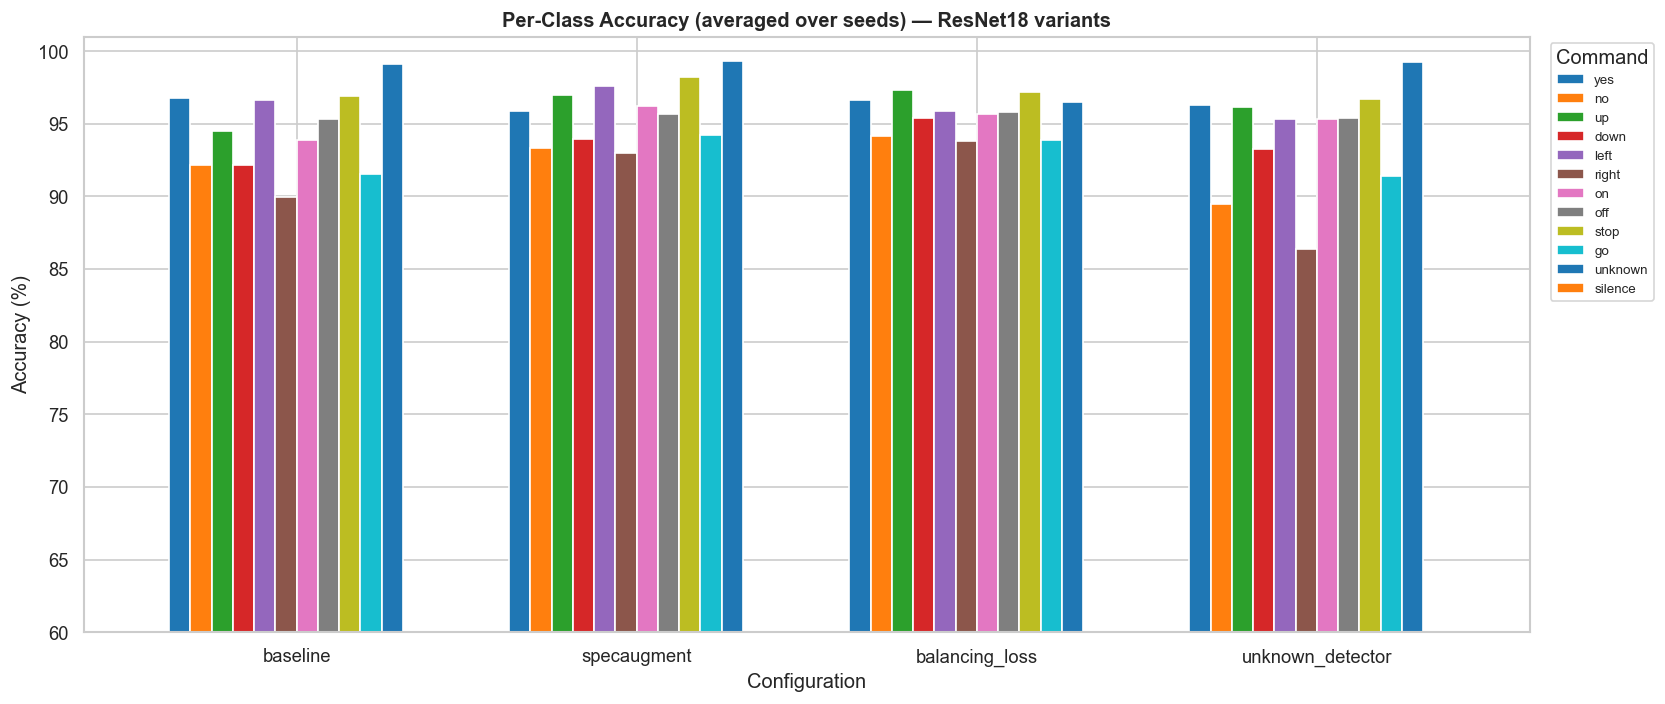


Per-class accuracy table:


In [7]:
CM_DIR = Path("../outputs/analysis/eval_no_override")

def load_avg_cm(exp_name):
    """Load all per-seed confusion matrices for an experiment and average them."""
    cms, class_names = [], []
    for jf in sorted(CM_DIR.glob(f"{exp_name}_seed*_no_override_confusion_matrix.json")):
        d = json.loads(jf.read_text())
        if not class_names:
            class_names = d.get("class_names", [])
        cm = np.array(d.get("confusion_matrix", []))
        if cm.size:
            cms.append(cm)
    if not cms:
        return None, None
    return np.mean(cms, axis=0), class_names

def per_class_acc(cm):
    row_sums = cm.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1
    return (cm.diagonal() / row_sums.squeeze()) * 100

configs_to_compare = {
    "baseline":         "resnet18_full_baseline",
    "specaugment":      "resnet18_full_specaugment",
    "balancing_loss":   "resnet18_full_balancing_loss",
    "unknown_detector": "resnet18_full_unknown_detector",
}

class_accs = {}
class_names_ref = None
for label, exp in configs_to_compare.items():
    cm, names = load_avg_cm(exp)
    if cm is not None:
        class_accs[label] = per_class_acc(cm)
        if class_names_ref is None:
            class_names_ref = names

if class_accs and class_names_ref:
    df_cls = pd.DataFrame(class_accs, index=class_names_ref)

    fig, ax = plt.subplots(figsize=(14, 6))
    df_cls.T.plot(kind="bar", ax=ax, width=0.75, edgecolor="white")
    ax.set_title("Per-Class Accuracy (averaged over seeds) — ResNet18 variants", fontweight="bold")
    ax.set_ylabel("Accuracy (%)")
    ax.set_xlabel("Configuration")
    ax.legend(title="Command", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
    ax.set_ylim(60, 101)
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.savefig("visualizations/per_class_accuracy_new.png", bbox_inches="tight")
    plt.show()

    print("\nPer-class accuracy table:")
    df_cls.round(1)
else:
    print("No confusion matrix files found — run eval_no_override first.")


## 7. Val vs Test Accuracy — Overfitting Check


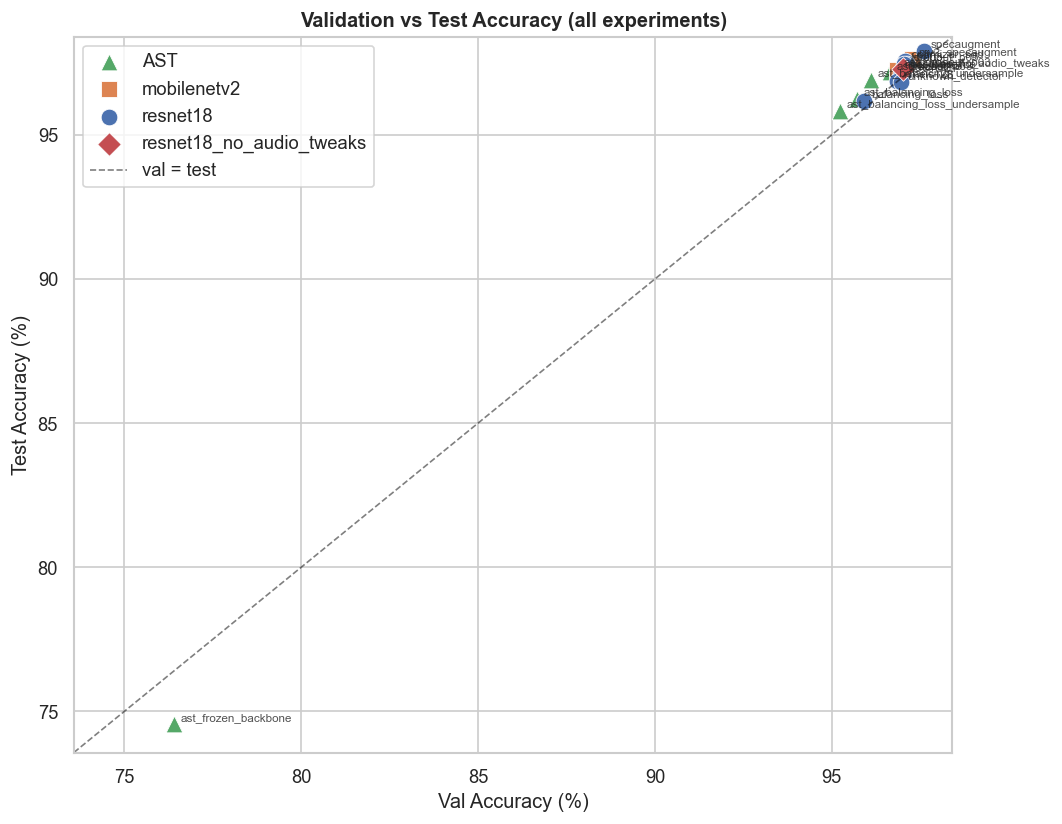

In [8]:
fig, ax = plt.subplots(figsize=(9, 7))

for arch, grp in df.groupby("Architecture"):
    color = palette_arch.get(arch, "grey")
    marker = markers_arch.get(arch, "o")
    ax.scatter(grp["Val Acc Mean"], grp["Test Acc Mean"],
               c=color, marker=marker, s=100, label=arch, edgecolors="white", linewidths=0.5)
    for _, row in grp.iterrows():
        ax.annotate(row["Label"], (row["Val Acc Mean"], row["Test Acc Mean"]),
                    textcoords="offset points", xytext=(4, 2), fontsize=7, alpha=0.8)

lims = [min(df["Val Acc Mean"].min(), df["Test Acc Mean"].min()) - 1,
        max(df["Val Acc Mean"].max(), df["Test Acc Mean"].max()) + 0.5]
ax.plot(lims, lims, "k--", linewidth=1, alpha=0.5, label="val = test")
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel("Val Accuracy (%)"); ax.set_ylabel("Test Accuracy (%)")
ax.set_title("Validation vs Test Accuracy (all experiments)", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig("visualizations/val_vs_test_acc.png", bbox_inches="tight")
plt.show()


## 8. Full Results Table


In [9]:
cols_show = ["Experiment", "Architecture", "Seeds",
             "Test Acc Mean", "Test Acc Std", "Test F1 Mean", "Test F1 Std",
             "Val Acc Mean", "Train Time Mean (min)", "Inference Latency Mean (ms)",
             "No Ov Test Acc Mean", "No Ov Sil Test Acc Mean"]

styled = (df[cols_show]
    .sort_values(["Architecture", "Test Acc Mean"], ascending=[True, False])
    .reset_index(drop=True)
    .style
    .background_gradient(subset=["Test Acc Mean", "Test F1 Mean"], cmap="YlGn")
    .format({c: "{:.2f}" for c in cols_show if df[c].dtype == float}, na_rep="—")
)
styled


,Experiment,Architecture,Seeds,Test Acc Mean,Test Acc Std,Test F1 Mean,Test F1 Std,Val Acc Mean,Train Time Mean (min),Inference Latency Mean (ms),No Ov Test Acc Mean,No Ov Sil Test Acc Mean
0,ast_full_dropout_p03,AST,4,97.28,0.35,87.86,0.49,96.83,339.65,6.10,—,—
1,ast_full_baseline,AST,4,97.18,0.06,87.68,0.10,96.64,312.46,6.09,—,—
2,ast_full_balancing_undersample,AST,4,96.90,0.20,87.30,0.26,96.10,163.73,6.11,—,—
3,ast_full_balancing_loss,AST,4,96.24,0.86,86.24,1.24,95.70,388.97,6.10,—,—
4,ast_full_balancing_loss_undersample,AST,4,95.84,0.57,85.74,0.76,95.24,197.25,6.11,—,—
5,ast_full_frozen_backbone,AST,4,74.58,0.34,48.70,1.04,76.39,182.19,6.11,—,—
6,mobilenetv2_full_specaugment,mobilenetv2,4,97.65,0.13,96.37,0.28,97.26,109.37,1.52,—,—
7,mobilenetv2_full_baseline,mobilenetv2,4,97.26,0.12,95.82,0.26,96.86,62.97,1.11,—,—
8,resnet18_full_specaugment,resnet18,4,97.91,0.20,96.87,0.39,97.61,61.18,1.03,97.91,97.98
9,resnet18_full_optimizer_sgd,resnet18,4,97.57,0.14,96.23,0.20,97.06,75.35,0.60,97.57,97.65


## 9. Accuracy Comparison — All Configurations (grouped by architecture)


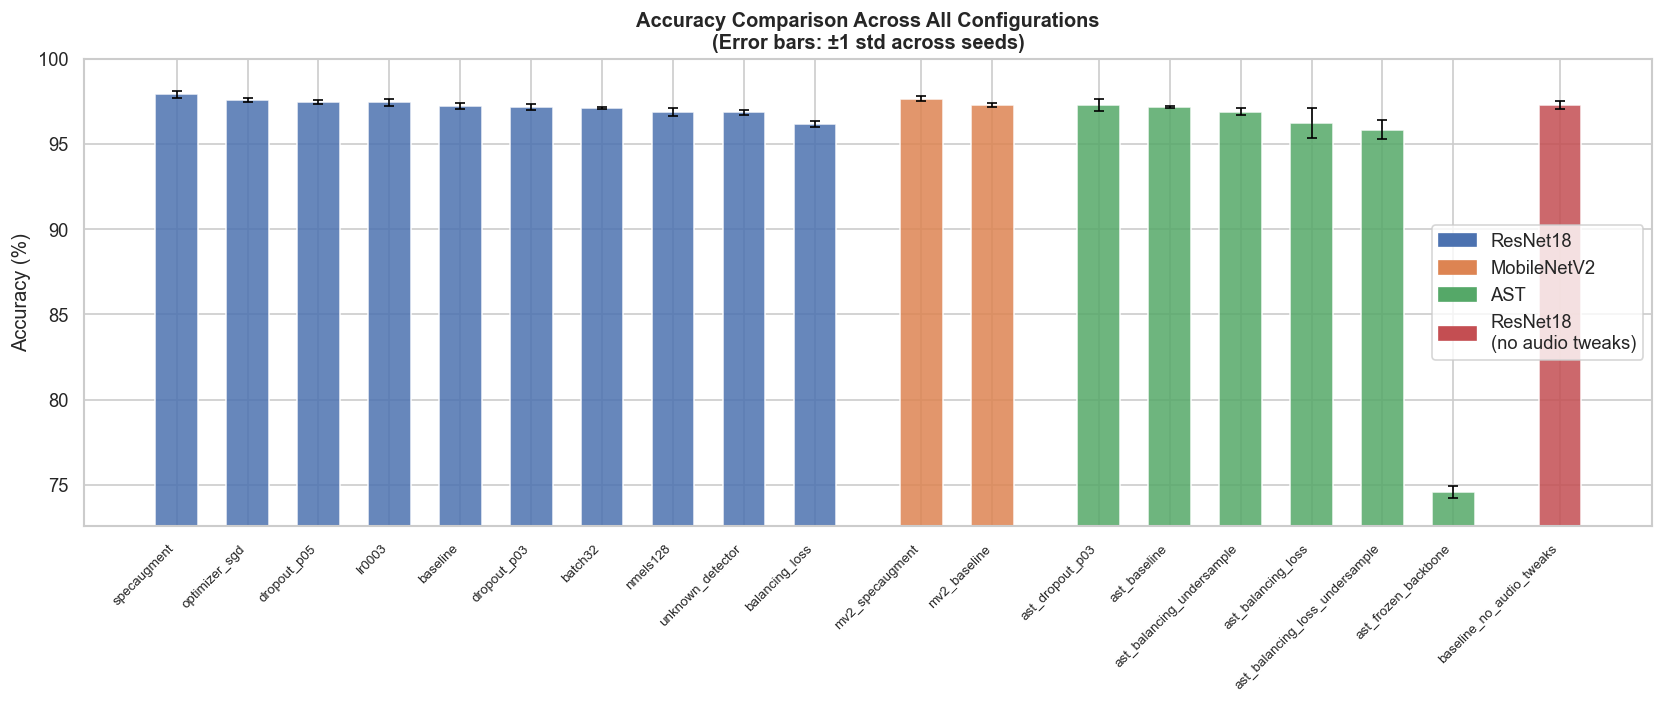

In [10]:
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(14, 6))

x = 0
x_ticks, x_labels = [], []
for arch in arch_order:
    grp = df[df["Architecture"] == arch].sort_values("Test Acc Mean", ascending=False)
    if grp.empty:
        continue
    for _, row in grp.iterrows():
        err = row["Test Acc Std"] if pd.notna(row["Test Acc Std"]) else 0
        ax.bar(x, row["Test Acc Mean"], 0.6,
               color=palette_arch.get(arch, "grey"), alpha=0.85,
               yerr=err, capsize=3, error_kw={"linewidth": 1})
        x_ticks.append(x)
        x_labels.append(row["Label"])
        x += 1
    x += 0.5  # gap between architecture groups

ax.set_xticks(x_ticks)
ax.set_xticklabels(x_labels, rotation=45, ha="right", fontsize=8)
ax.set_ylabel("Accuracy (%)")
ax.set_title("Accuracy Comparison Across All Configurations\n(Error bars: ±1 std across seeds)", fontweight="bold")
ax.set_ylim(df["Test Acc Mean"].min() - 2, 100)

patches = [mpatches.Patch(color=palette_arch[a], label=arch_labels.get(a, a))
           for a in arch_order if a in palette_arch]
ax.legend(handles=patches)
plt.tight_layout()
plt.savefig("visualizations/accuracy_comparison.png", bbox_inches="tight")
plt.show()


## 10. Test Accuracy — All Configurations Sorted (horizontal bar)


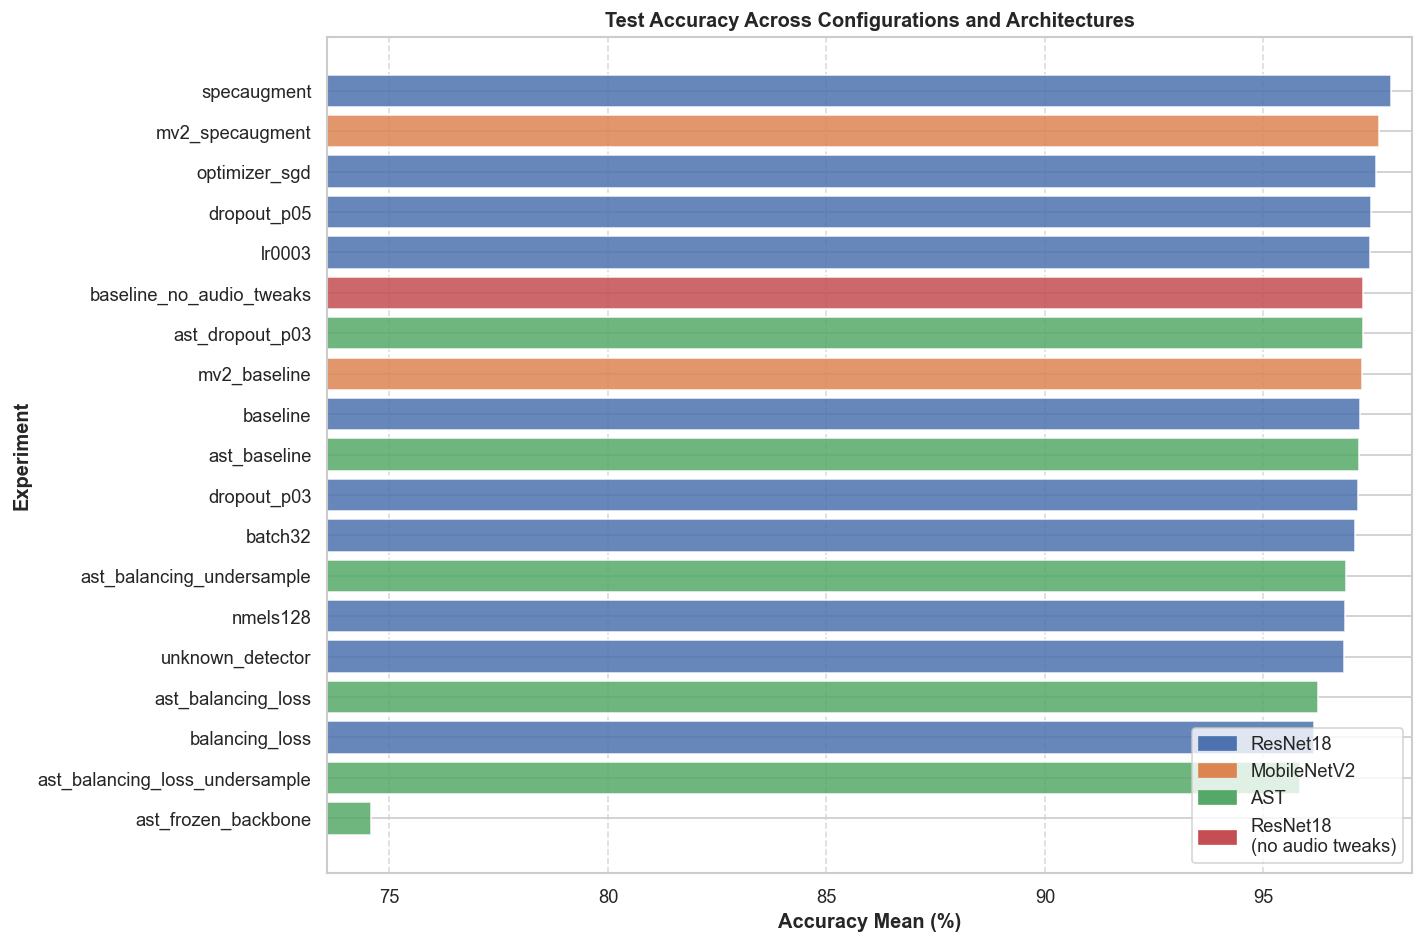

In [11]:
df_plot = df.sort_values("Test Acc Mean", ascending=True).copy()
colors = [palette_arch.get(a, "grey") for a in df_plot["Architecture"]]

fig, ax = plt.subplots(figsize=(12, 8))
ax.barh(df_plot["Label"], df_plot["Test Acc Mean"], color=colors, alpha=0.85, edgecolor="white")
ax.set_xlabel("Accuracy Mean (%)", fontweight="bold")
ax.set_ylabel("Experiment", fontweight="bold")
ax.set_title("Test Accuracy Across Configurations and Architectures", fontweight="bold")
ax.xaxis.grid(True, linestyle="--", alpha=0.7)
ax.set_axisbelow(True)
xlim_min = max(df["Test Acc Mean"].min() - 1, 0)
ax.set_xlim(xlim_min, df["Test Acc Mean"].max() + 0.5)

patches = [mpatches.Patch(color=palette_arch[a], label=arch_labels.get(a, a))
           for a in arch_order if a in palette_arch]
ax.legend(handles=patches)
plt.tight_layout()
plt.savefig("visualizations/accuracy_comparison_all_configs.png", bbox_inches="tight")
plt.show()


## 11. Per-Class Accuracy — Best Configuration per Architecture

Best configs: ResNet18 (`specaugment`), AST (`dropout_p03`), MobileNetV2 (`specaugment`).  
Confusion matrices averaged over all seeds.


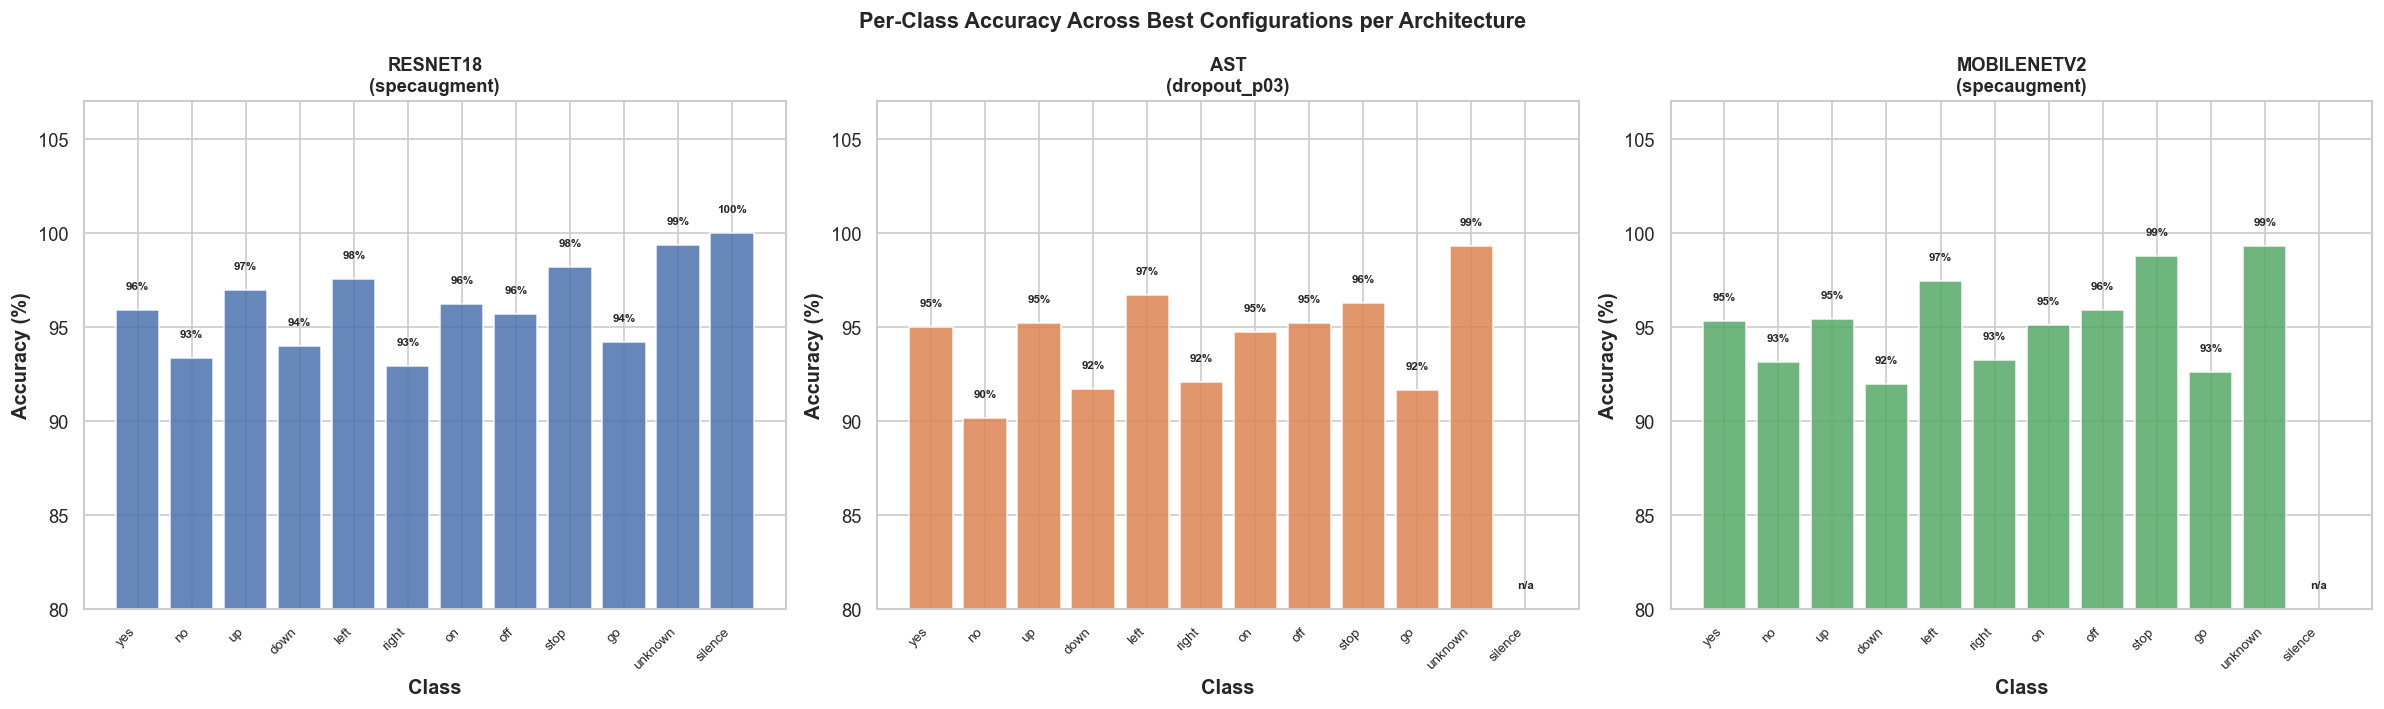

In [18]:
OUTPUTS_DIR = Path("../outputs")

def _load_cm_avg(paths, cm_key, label_key):
    """Load and average confusion matrices across seeds."""
    cms, labels = [], []
    for jf in sorted(paths):
        d = json.loads(jf.read_text())
        if not labels:
            labels = d.get(label_key, [])
        cm = np.array(d.get(cm_key, []))
        if cm.size:
            cms.append(cm)
    return (np.mean(cms, axis=0), labels) if cms else (None, [])

def load_r18_cm(exp_name):
    """Prefer eval_no_override_with_silence; fall back to eval_no_override."""
    sil_dir = OUTPUTS_DIR / "analysis" / "eval_no_override_with_silence"
    sil_paths = sorted(sil_dir.glob(f"{exp_name}_seed*_no_override_with_silence_confusion_matrix.json"))
    if sil_paths:
        return _load_cm_avg(sil_paths, "confusion_matrix", "class_names")
    no_ov_dir = OUTPUTS_DIR / "analysis" / "eval_no_override"
    paths = sorted(no_ov_dir.glob(f"{exp_name}_seed*_no_override_confusion_matrix.json"))
    return _load_cm_avg(paths, "confusion_matrix", "class_names")

def load_ast_cm(exp_name):
    paths = [d / f"confusion_matrix_seed{d.name.split('_seed')[-1]}.json"
             for d in sorted((OUTPUTS_DIR / "ast").glob(f"{exp_name}_seed*"))
             if d.is_dir()]
    paths = [p for p in paths if p.exists()]
    return _load_cm_avg(paths, "matrix", "labels")

def load_mv2_cm(exp_name):
    paths = [d / f"confusion_matrix_seed{d.name.split('_seed')[-1]}.json"
             for d in sorted((OUTPUTS_DIR / "mobilenetv2").glob(f"{exp_name}_seed*"))
             if d.is_dir()]
    paths = [p for p in paths if p.exists()]
    return _load_cm_avg(paths, "confusion_matrix", "class_names")

def per_class_acc_pct(cm):
    row_sums = cm.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1
    return (cm.diagonal() / row_sums.squeeze()) * 100

# Best configs per architecture
BEST = [
    ("resnet18_full_specaugment",      load_r18_cm,  "RESNET18\n(specaugment)",      "#4C72B0"),
    ("ast_full_dropout_p03",           load_ast_cm,  "AST\n(dropout_p03)",            "#DD8452"),
    ("mobilenetv2_full_specaugment",   load_mv2_cm,  "MOBILENETV2\n(specaugment)",    "#55A868"),
]

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle("Per-Class Accuracy Across Best Configurations per Architecture",
             fontsize=13, fontweight="bold")

for ax, (exp, loader, title, color) in zip(axes, BEST):
    cm, class_names = loader(exp)
    if cm is None:
        ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(title)
        continue

    accs = per_class_acc_pct(cm)
    row_sums = cm.sum(axis=1)

    bar_alphas = [0.3 if row_sums[i] == 0 else 0.85 for i in range(len(class_names))]
    for i, (cn, acc, alpha) in enumerate(zip(class_names, accs, bar_alphas)):
        ax.bar(i, acc if row_sums[i] > 0 else 0, color=color, alpha=alpha, edgecolor="white")
        label = "n/a" if row_sums[i] == 0 else f"{int(round(acc))}%"
        ax.text(i, 1 + (acc if row_sums[i] > 0 else 80),
                label, ha="center", va="bottom", fontsize=7, fontweight="bold")

    ax.set_ylim(80, 107)
    ax.set_xticks(range(len(class_names)))
    ax.set_xticklabels(class_names, rotation=45, ha="right", fontsize=8)
    ax.set_xlabel("Class", fontweight="bold")
    ax.set_ylabel("Accuracy (%)", fontweight="bold")
    ax.set_title(title, fontweight="bold", fontsize=11)

plt.tight_layout()
plt.savefig("visualizations/confusion_matrices_multi_architecture.png", bbox_inches="tight")
plt.show()


## 12. ResNet18 Confusion Matrices — Multiple Configurations (Seed 42)


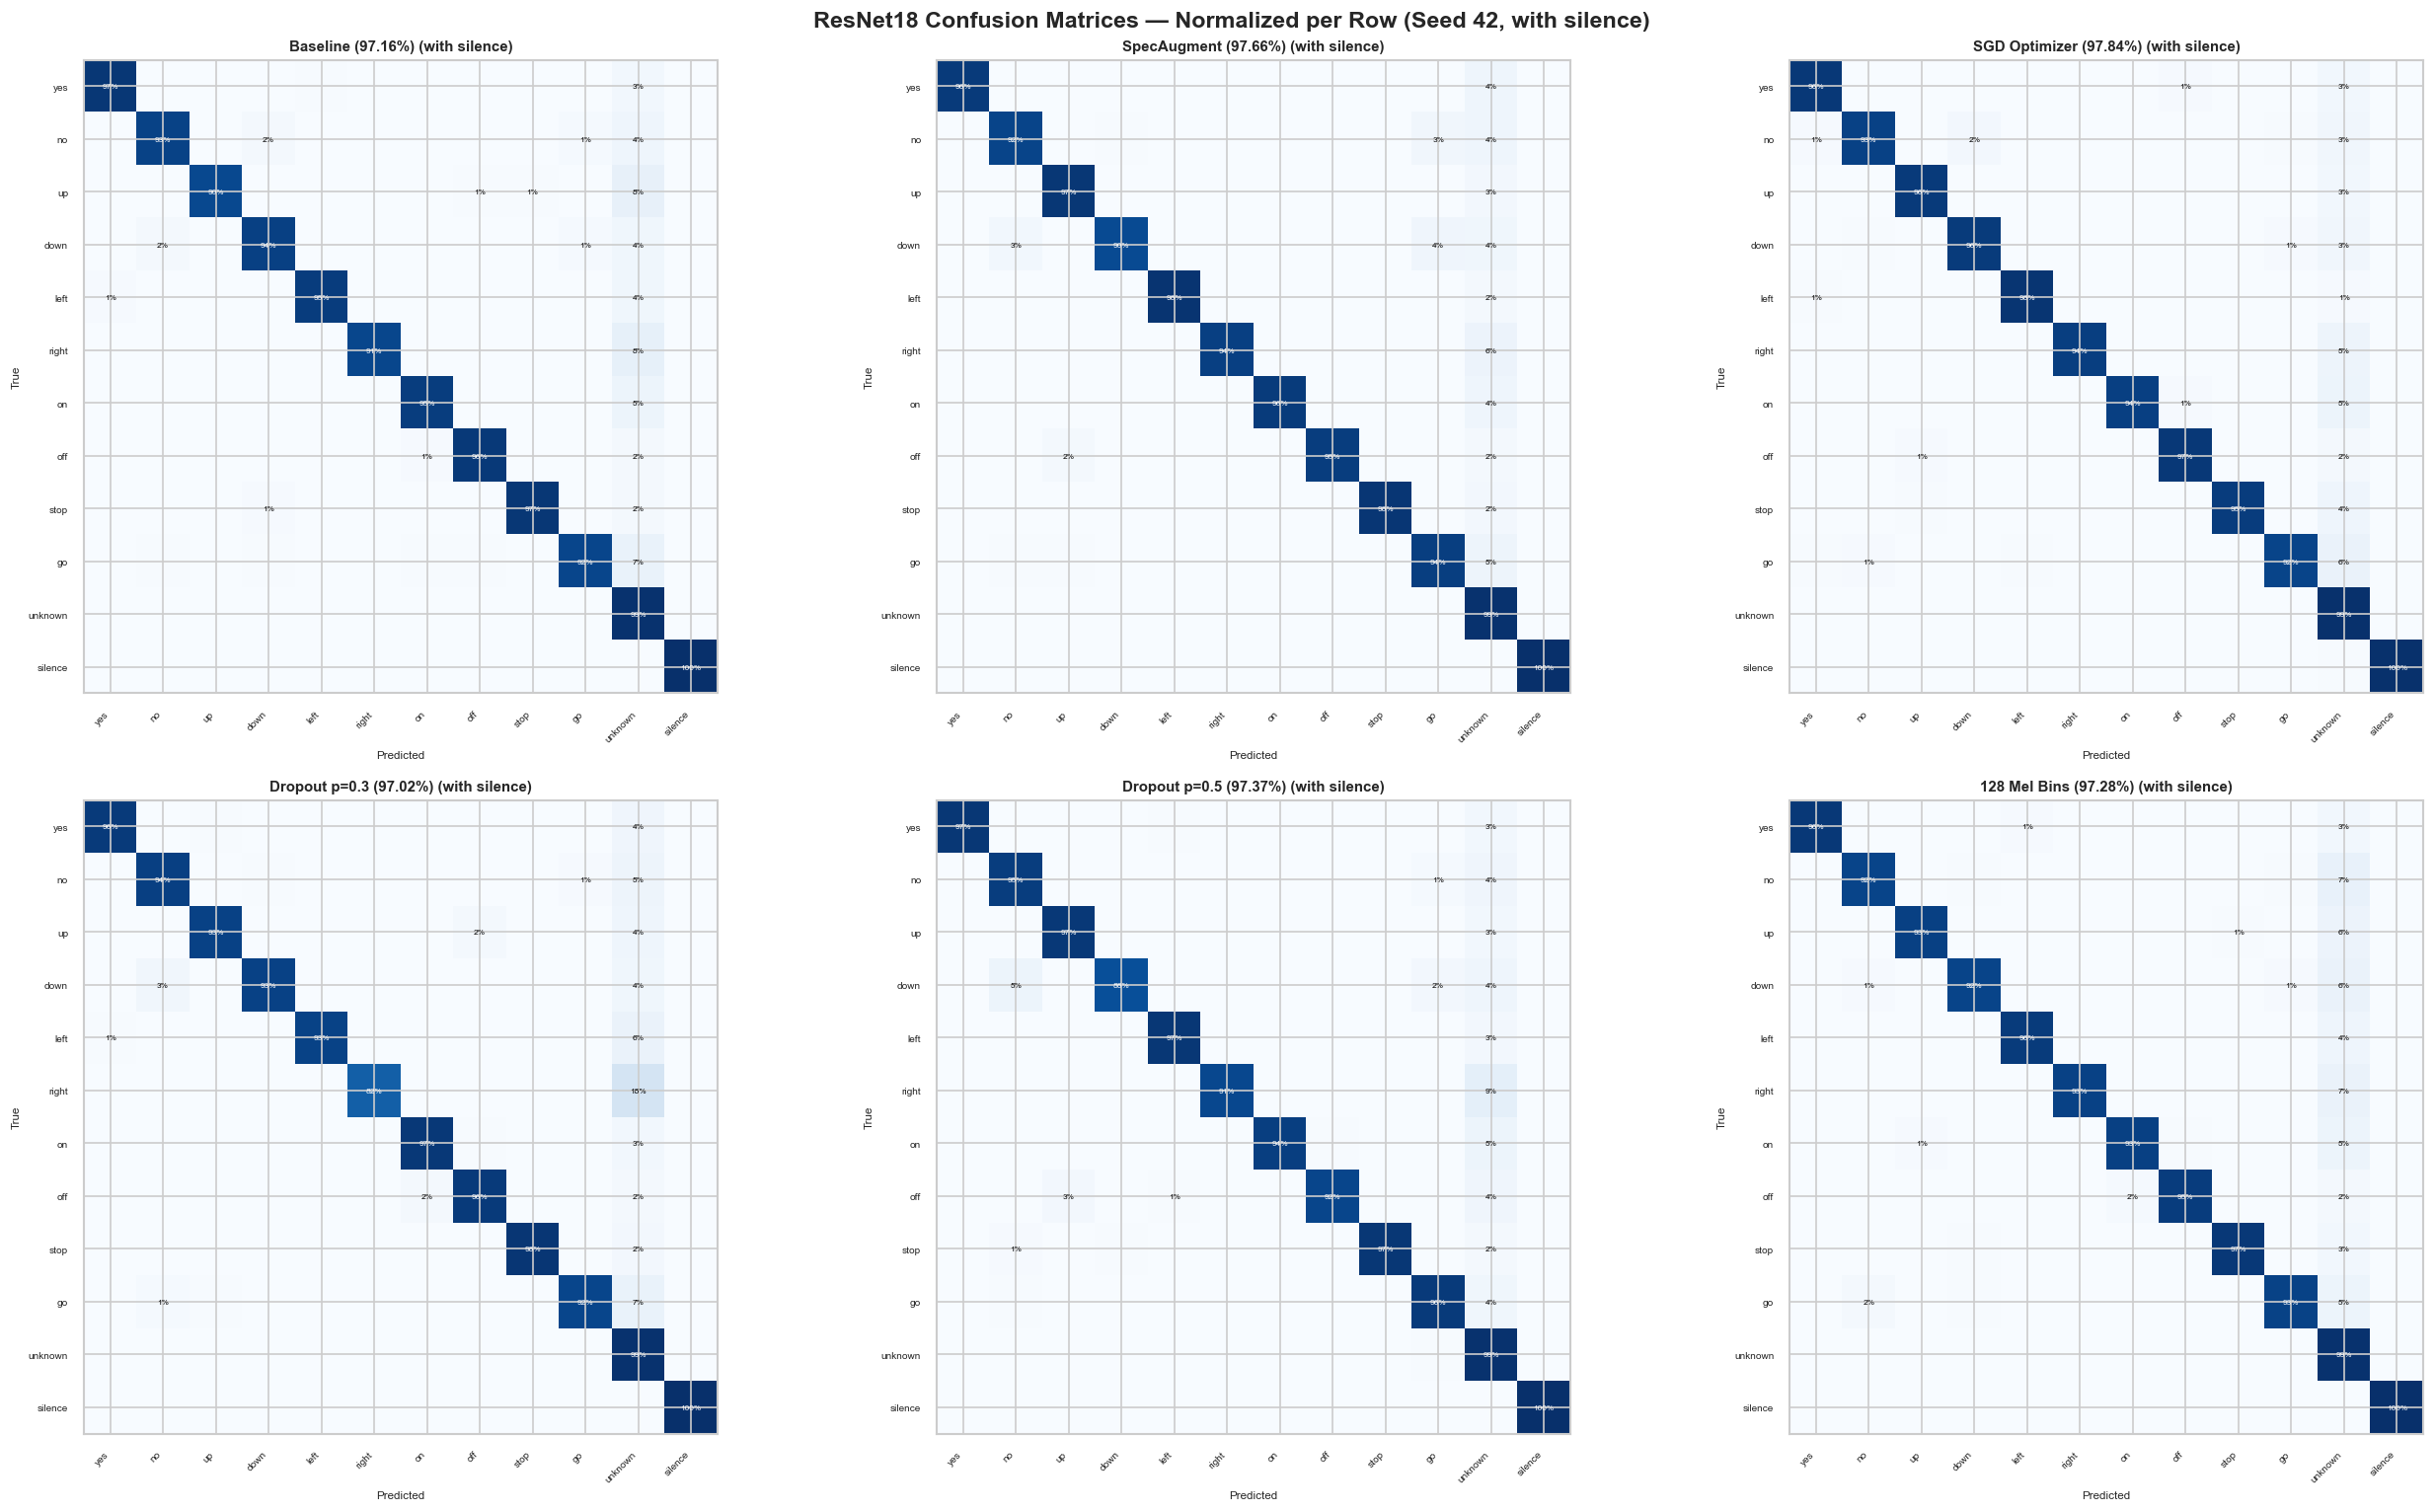

In [17]:
CONFIGS_R18 = {
    "Baseline":       "resnet18_full_baseline",
    "SpecAugment":    "resnet18_full_specaugment",
    "SGD Optimizer":  "resnet18_full_optimizer_sgd",
    "Dropout p=0.3":  "resnet18_full_dropout_p03",
    "Dropout p=0.5":  "resnet18_full_dropout_p05",
    "128 Mel Bins":   "resnet18_full_nmels128",
}
SEED_ID = "42"
SIL_CM_DIR = Path("../outputs/analysis/eval_no_override_with_silence")
R18_DIR    = Path("../outputs/resnet18")

def resolve_cm_path(exp_name, seed):
    """Use eval_no_override_with_silence if available, else fall back to standard eval."""
    sil = SIL_CM_DIR / f"{exp_name}_seed{seed}_no_override_with_silence_confusion_matrix.json"
    if sil.exists():
        return sil, "(with silence)"
    std = R18_DIR / f"{exp_name}_seed{seed}" / f"confusion_matrix_seed{seed}.json"
    return (std, "(standard)") if std.exists() else (None, "")

fig, axes = plt.subplots(2, 3, figsize=(22, 13))
axes = axes.flatten()
fig.suptitle(
    f"ResNet18 Confusion Matrices — Normalized per Row (Seed {SEED_ID}, with silence)",
    fontsize=14, fontweight="bold"
)

for ax, (title, exp_name) in zip(axes, CONFIGS_R18.items()):
    jf, source_label = resolve_cm_path(exp_name, SEED_ID)
    if jf is None:
        ax.set_visible(False)
        continue
    d = json.loads(jf.read_text())
    cm_raw = np.array(d["confusion_matrix"])
    if "confusion_matrix_normalized" in d:
        cm_norm = np.array(d["confusion_matrix_normalized"])
    else:
        row_sums = cm_raw.sum(axis=1, keepdims=True)
        row_sums[row_sums == 0] = 1
        cm_norm = cm_raw / row_sums
    class_names = d["class_names"]
    acc = np.trace(cm_raw) / cm_raw.sum() * 100

    ax.imshow(cm_norm, interpolation="nearest", cmap="Blues", vmin=0, vmax=1)
    ax.set_title(f"{title} ({acc:.2f}%) {source_label}", fontsize=9, fontweight="bold")
    ticks = np.arange(len(class_names))
    ax.set_xticks(ticks); ax.set_xticklabels(class_names, rotation=45, ha="right", fontsize=6)
    ax.set_yticks(ticks); ax.set_yticklabels(class_names, fontsize=6)
    ax.set_xlabel("Predicted", fontsize=7); ax.set_ylabel("True", fontsize=7)
    thresh = 0.5
    for i in range(len(class_names)):
        for j in range(len(class_names)):
            val = cm_norm[i, j]
            if val > 0.005:
                ax.text(j, i, f"{val:.0%}", ha="center", va="center",
                        fontsize=5, color="white" if val > thresh else "black")

plt.tight_layout()
plt.savefig("visualizations/resnet18_confusion_matrices.png", bbox_inches="tight")
plt.show()


## 13. Training Curves — Learning Dynamics (Seed 42)

Compare loss and accuracy trajectories across key configurations and architectures.


In [ ]:
OUTPUTS = Path("../outputs")
SEED = 42

def load_history(model_dir, exp_seed_dir, seed=42):
    path = OUTPUTS / model_dir / exp_seed_dir / f"history_seed{seed}.csv"
    if path.exists():
        return pd.read_csv(path)
    return None

CNN_CONFIGS = {
    "ResNet18 Baseline":   ("resnet18",    "resnet18_full_baseline_seed42"),
    "ResNet18 SpecAugment":("resnet18",    "resnet18_full_specaugment_seed42"),
    "ResNet18 SGD":        ("resnet18",    "resnet18_full_optimizer_sgd_seed42"),
    "ResNet18 Drop 0.3":   ("resnet18",    "resnet18_full_dropout_p03_seed42"),
    "MobileNetV2 Base":    ("mobilenetv2", "mobilenetv2_full_baseline_seed42"),
    "MobileNetV2 SpecAug": ("mobilenetv2", "mobilenetv2_full_specaugment_seed42"),
}
AST_CONFIGS = {
    "AST Baseline":    ("ast", "ast_full_baseline_seed42"),
    "AST Dropout 0.3": ("ast", "ast_full_dropout_p03_seed42"),
    "AST Frozen":      ("ast", "ast_full_frozen_backbone_seed42"),
}

all_configs = {**CNN_CONFIGS, **AST_CONFIGS}
hists = {label: load_history(mdir, edir, SEED) for label, (mdir, edir) in all_configs.items()}
hists = {k: v for k, v in hists.items() if v is not None}


fig, axes = plt.subplots(1, 2, figsize=(18, 5))
fig.suptitle("Training Dynamics — Loss (Seed 42)", fontweight="bold", fontsize=13)
cnn_palette = sns.color_palette("Blues_d", len(CNN_CONFIGS))
ast_palette  = sns.color_palette("Oranges_d", len(AST_CONFIGS))

for ax, (group_labels, group_colors, title) in zip(
    axes,
    [(CNN_CONFIGS, cnn_palette, "CNNs (ResNet18 & MobileNetV2)"),
     (AST_CONFIGS,  ast_palette,  "AST variants")],
):
    for (label, _), color in zip(group_labels.items(), group_colors):
        h = hists.get(label)
        if h is None:
            continue
        col = "epoch" if "epoch" in h.columns else h.columns[0]
        ax.plot(h[col], h["train_loss"], linestyle="--", color=color, alpha=0.5, linewidth=1)
        ax.plot(h[col], h["val_loss"],   linestyle="-",  color=color, label=label, linewidth=1.8)
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Cross-Entropy Loss")
    ax.legend(fontsize=8, title="Val (solid) / Train (dashed)")

plt.tight_layout()
plt.savefig("visualizations/training_curves_loss.png", bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
fig.suptitle("Training Dynamics — Accuracy (Seed 42)", fontweight="bold", fontsize=13)

for ax, (group_labels, group_colors, title) in zip(
    axes,
    [(CNN_CONFIGS, cnn_palette, "CNNs (ResNet18 & MobileNetV2)"),
     (AST_CONFIGS,  ast_palette,  "AST variants")],
):
    for (label, _), color in zip(group_labels.items(), group_colors):
        h = hists.get(label)
        if h is None:
            continue
        col = "epoch" if "epoch" in h.columns else h.columns[0]
        ax.plot(h[col], h["train_accuracy"] * 100, linestyle="--", color=color, alpha=0.5, linewidth=1)
        ax.plot(h[col], h["val_accuracy"]   * 100, linestyle="-",  color=color, label=label, linewidth=1.8)
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Accuracy (%)")
    ax.legend(fontsize=8, title="Val (solid) / Train (dashed)")

plt.tight_layout()
plt.savefig("visualizations/training_curves_acc.png", bbox_inches="tight")
plt.show()


## 14. Seed Stability — Test Accuracy Distribution Across 4 Seeds

Box plots showing how each configuration varies across seeds 42, 123, 2026, 2137.


In [ ]:
SEEDS = [42, 123, 2026, 2137]

def collect_per_seed_acc(model_dir, exp_base):
    """Load per-seed test accuracy from summary JSON files."""
    accs = {}
    for seed in SEEDS:
        summary_path = OUTPUTS / model_dir / f"{exp_base}_seed{seed}" / f"summary_seed{seed}.json"
        if not summary_path.exists():
            # try AST-style path
            summary_path = OUTPUTS / model_dir / f"{exp_base}_seed{seed}" / "summary.json"
        if summary_path.exists():
            d = json.loads(summary_path.read_text())
            # CNN: d["test_accuracy"], AST: d["test_accuracy"]
            acc = d.get("test_accuracy", d.get("test_acc", None))
            if acc is not None:
                accs[seed] = acc * 100
    return accs

SEED_CONFIGS = {
    ("ResNet18", "baseline"):    ("resnet18",    "resnet18_full_baseline"),
    ("ResNet18", "specaugment"): ("resnet18",    "resnet18_full_specaugment"),
    ("ResNet18", "sgd"):         ("resnet18",    "resnet18_full_optimizer_sgd"),
    ("ResNet18", "dropout_p03"): ("resnet18",    "resnet18_full_dropout_p03"),
    ("ResNet18", "nmels128"):    ("resnet18",    "resnet18_full_nmels128"),
    ("AST",      "baseline"):    ("ast",         "ast_full_baseline"),
    ("AST",      "dropout_p03"): ("ast",         "ast_full_dropout_p03"),
    ("AST",      "bal_loss"):    ("ast",         "ast_full_balancing_loss"),
    ("MNV2",     "baseline"):    ("mobilenetv2", "mobilenetv2_full_baseline"),
    ("MNV2",     "specaugment"): ("mobilenetv2", "mobilenetv2_full_specaugment"),
}

records = []
for (arch, variant), (model_dir, exp_base) in SEED_CONFIGS.items():
    per_seed = collect_per_seed_acc(model_dir, exp_base)
    for seed, acc in per_seed.items():
        records.append({"Architecture": arch, "Variant": variant,
                         "Label": f"{arch}\n{variant}", "Seed": seed, "Test Acc (%)": acc})

df_seeds = pd.DataFrame(records)

# Sort by mean acc within architecture
order = (df_seeds.groupby("Label")["Test Acc (%)"]
         .mean()
         .sort_values(ascending=False)
         .index.tolist())

fig, ax = plt.subplots(figsize=(16, 6))
arch_colors_map = {"ResNet18": "#4C72B0", "AST": "#DD8452", "MNV2": "#55A868"}
palette_seed = {lbl: arch_colors_map.get(lbl.split("\n")[0], "grey") for lbl in order}

sns.boxplot(data=df_seeds, x="Label", y="Test Acc (%)", order=order,
            palette=palette_seed, linewidth=1.5, flierprops=dict(marker="o", markersize=5),
            ax=ax)
sns.stripplot(data=df_seeds, x="Label", y="Test Acc (%)", order=order,
              color="black", size=4.5, alpha=0.7, jitter=True, ax=ax)

ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right", fontsize=9)
ax.set_xlabel("")
ax.set_ylabel("Test Accuracy (%)", fontweight="bold")
ax.set_title("Test Accuracy Distribution Across 4 Seeds (42, 123, 2026, 2137)", fontweight="bold")
ax.yaxis.grid(True, linestyle="--", alpha=0.7)
ax.set_axisbelow(True)

patches = [mpatches.Patch(color=c, label=a) for a, c in arch_colors_map.items()]
ax.legend(handles=patches, title="Architecture", fontsize=9)

plt.tight_layout()
plt.savefig("visualizations/seed_stability.png", bbox_inches="tight")
plt.show()

print("\nSeed variance summary (std dev):")
df_seeds.groupby("Label")["Test Acc (%)"].agg(["mean", "std"]).sort_values("mean", ascending=False).round(3)


## 15. Unknown & Silence Class Analysis — Precision and Recall Heatmap

Detailed look at how well each configuration handles the two minority/challenging classes.


In [ ]:
def load_error_analysis(model_dir, exp_base, seed):
    """Return the unknown_silence_analysis dict for one seed, or None."""
    path = OUTPUTS / model_dir / f"{exp_base}_seed{seed}" / f"error_analysis_seed{seed}.json"
    if not path.exists():
        return None
    d = json.loads(path.read_text())
    return d.get("unknown_silence_analysis", None)

ANALYSIS_CONFIGS = {
    "R18-baseline":    ("resnet18",    "resnet18_full_baseline"),
    "R18-specaug":     ("resnet18",    "resnet18_full_specaugment"),
    "R18-bal_loss":    ("resnet18",    "resnet18_full_balancing_loss"),
    "R18-bal_under":   ("resnet18",    "resnet18_full_balancing_undersample"),
    "R18-bal_both":    ("resnet18",    "resnet18_full_balancing_loss_undersample"),
    "R18-unk_det":     ("resnet18",    "resnet18_full_unknown_detector"),
    "AST-baseline":    ("ast",         "ast_full_baseline"),
    "AST-dropout":     ("ast",         "ast_full_dropout_p03"),
    "AST-bal_loss":    ("ast",         "ast_full_balancing_loss"),
    "MNV2-baseline":   ("mobilenetv2", "mobilenetv2_full_baseline"),
    "MNV2-specaug":    ("mobilenetv2", "mobilenetv2_full_specaugment"),
}

metrics_data = {"unknown_precision": {}, "unknown_recall": {},
                "silence_precision": {}, "silence_recall": {}}

for label, (mdir, exp_base) in ANALYSIS_CONFIGS.items():
    up_vals, ur_vals, sp_vals, sr_vals = [], [], [], []
    for seed in SEEDS:
        ea = load_error_analysis(mdir, exp_base, seed)
        if ea is None:
            continue
        unk = ea.get("unknown", {})
        sil = ea.get("silence", {})
        if unk.get("precision") is not None: up_vals.append(unk["precision"])
        if unk.get("recall")    is not None: ur_vals.append(unk["recall"])
        if sil.get("precision") is not None: sp_vals.append(sil["precision"])
        if sil.get("recall")    is not None: sr_vals.append(sil["recall"])
    def _mean(lst): return np.mean(lst) * 100 if lst else np.nan
    metrics_data["unknown_precision"][label] = _mean(up_vals)
    metrics_data["unknown_recall"][label]    = _mean(ur_vals)
    metrics_data["silence_precision"][label] = _mean(sp_vals)
    metrics_data["silence_recall"][label]    = _mean(sr_vals)

hm_df = pd.DataFrame(metrics_data, index=list(ANALYSIS_CONFIGS.keys()))

# Keep only columns with non-all-NaN
hm_df = hm_df.dropna(axis=1, how="all")

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, (metric_pair, title, cmap) in zip(
    axes,
    [
        (["unknown_precision", "unknown_recall"], "Unknown Class\nPrecision & Recall (%)", "Blues"),
        (["silence_precision",  "silence_recall"],  "Silence Class\nPrecision & Recall (%)",  "Greens"),
    ]
):
    cols = [c for c in metric_pair if c in hm_df.columns]
    if not cols:
        ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes)
        continue
    subset = hm_df[cols].copy()
    subset.columns = [c.split("_")[-1].capitalize() for c in cols]
    sns.heatmap(subset, annot=True, fmt=".1f", cmap=cmap, vmin=0, vmax=100,
                linewidths=0.5, ax=ax, cbar_kws={"label": "%"})
    ax.set_title(title, fontweight="bold", fontsize=11)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.tick_params(axis="x", rotation=0)
    ax.tick_params(axis="y", rotation=0)

fig.suptitle("Per-Class Precision & Recall for Silence and Unknown (mean over seeds)",
             fontweight="bold", fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig("visualizations/unknown_silence_heatmap.png", bbox_inches="tight")
plt.show()

print("\nFull heatmap data:")
hm_df.round(2)


## 16. Balancing Strategy Comparison — ResNet18 and AST

Direct comparison of four class-imbalance handling strategies across both architectures.


In [ ]:
BAL_STRATEGIES = {
    "None":             "baseline",
    "Weighted loss":    "balancing_loss",
    "Undersample":      "balancing_undersample",
    "Loss+Undersample": "balancing_loss_undersample",
}

R18_BAL_EXPS = {s: f"resnet18_full_{v}" for s, v in [
    ("None",             "baseline"),
    ("Weighted loss",    "balancing_loss"),
    ("Undersample",      "balancing_undersample"),
    ("Loss+Undersample", "balancing_loss_undersample"),
]}
AST_BAL_EXPS = {s: f"ast_full_{v}" for s, v in [
    ("None",             "baseline"),
    ("Weighted loss",    "balancing_loss"),
    ("Undersample",      "balancing_undersample"),
    ("Loss+Undersample", "balancing_loss_undersample"),
]}

def get_acc_f1(arch_col, exp_name):
    row = df[df["Experiment"] == exp_name]
    if row.empty:
        return np.nan, np.nan
    return float(row["Test Acc Mean"].iloc[0]), float(row["Test F1 Mean"].iloc[0])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Effect of Class Balancing Strategies on Accuracy and Macro-F1", fontweight="bold", fontsize=13)

for ax, (arch_name, arch_exps, arch_col) in zip(axes, [
    ("ResNet18", R18_BAL_EXPS, "ResNet18"),
    ("AST",       AST_BAL_EXPS,  "AST"),
]):
    strategies = list(arch_exps.keys())
    accs, f1s  = [], []
    for s in strategies:
        acc, f1 = get_acc_f1(arch_col, arch_exps[s])
        accs.append(acc)
        f1s.append(f1)

    x = np.arange(len(strategies))
    w = 0.35
    bars_acc = ax.bar(x - w/2, accs, w, label="Accuracy", color="#4C72B0", alpha=0.85, edgecolor="white")
    bars_f1  = ax.bar(x + w/2, f1s,  w, label="Macro-F1", color="#55A868", alpha=0.85, edgecolor="white")

    ax.set_xticks(x)
    ax.set_xticklabels(strategies, fontsize=10)
    ax.set_ylabel("Score (%)")
    ax.set_title(f"{arch_name} — Balancing Strategies", fontweight="bold")
    ax.legend()
    valid = [v for v in accs + f1s if not np.isnan(v)]
    if valid:
        ax.set_ylim(min(valid) - 5, 101)
    ax.yaxis.grid(True, linestyle="--", alpha=0.6)
    ax.set_axisbelow(True)

    # Annotate bars
    for bar in bars_acc:
        h = bar.get_height()
        if not np.isnan(h):
            ax.text(bar.get_x() + bar.get_width() / 2, h + 0.1, f"{h:.2f}",
                    ha="center", va="bottom", fontsize=8)
    for bar in bars_f1:
        h = bar.get_height()
        if not np.isnan(h):
            ax.text(bar.get_x() + bar.get_width() / 2, h + 0.1, f"{h:.2f}",
                    ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.savefig("visualizations/balancing_comparison.png", bbox_inches="tight")
plt.show()


## 17. Model Complexity vs Performance — Bubble Chart

Parameter count and inference latency versus test accuracy for all best-per-architecture configurations.


In [ ]:
# Approximate parameter counts (millions)
# ResNet18 base + adapted head: ~11.18M
# MobileNetV2 + adapted head:   ~2.24M
# AST (MIT/ast-finetuned-audioset-10-10-0.4593): ~86.50M

MODEL_SPECS = [
    # (Label, Arch, Params_M, Test_Acc, Test_F1, Latency_ms)
    ("ResNet18\nBaseline",    "ResNet18",    11.18, 97.21, 96.21, 0.46),
    ("ResNet18\nSpecAugment", "ResNet18",    11.18, 97.91, 96.87, 0.46),
    ("ResNet18\nSGD",         "ResNet18",    11.18, 97.57, 96.47, 0.46),
    ("ResNet18\nDrop 0.3",    "ResNet18",    11.18, 97.16, 96.11, 0.46),
    ("ResNet18\nn_mels=128",  "ResNet18",    11.18, 97.49, 96.27, 0.46),
    ("MobileNetV2\nBaseline", "MobileNetV2",  2.24, 97.26, 96.18, 1.11),
    ("MobileNetV2\nSpecAug",  "MobileNetV2",  2.24, 97.65, 96.37, 1.11),
    ("AST\nBaseline",         "AST",          86.5, 97.18, 87.68, 6.09),
    ("AST\nDropout 0.3",      "AST",          86.5, 97.28, 87.86, 6.09),
    ("AST\nFrozen",           "AST",          86.5, 74.58, 48.70, 6.09),
]

# Override with actual CSV values where available
for row in MODEL_SPECS:
    lbl, arch, params, acc, f1, lat = row
    exp_match = df[df["Architecture"] == arch]
    # just keep as-is from the manual data (already from CSV)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle("Model Complexity vs Performance", fontweight="bold", fontsize=13)

for ax, (x_key, x_label, log_x) in zip(
    axes,
    [("Params (M)", "Parameter Count (millions)", True),
     ("Latency (ms)", "Inference Latency (ms)", False)],
):
    for label, arch, params, acc, f1, lat in MODEL_SPECS:
        color = palette_arch.get(arch, "grey")
        marker = markers_arch.get(arch, "o")
        x_val = params if x_key == "Params (M)" else lat
        # Bubble size ~ F1
        size = max((f1 / 100) ** 2 * 1200, 20)
        ax.scatter(x_val, acc, s=size, c=color, marker=marker,
                   edgecolors="white", linewidths=0.8, alpha=0.85)
        ax.annotate(label, (x_val, acc), textcoords="offset points",
                    xytext=(6, 2), fontsize=6.5, alpha=0.9)

    if log_x:
        ax.set_xscale("log")
        ax.set_xlabel(f"{x_label} (log scale)", fontweight="bold")
    else:
        ax.set_xlabel(x_label, fontweight="bold")
    ax.set_ylabel("Test Accuracy (%)", fontweight="bold")
    ax.yaxis.grid(True, linestyle="--", alpha=0.6)
    ax.set_axisbelow(True)

# Shared legend
patches = [mpatches.Patch(color=palette_arch[a], label=arch_labels.get(a, a))
           for a in arch_order if a in palette_arch]
axes[0].legend(handles=patches, title="Architecture", fontsize=9)
axes[0].set_title("Parameter Count vs Accuracy\n(bubble size ∝ Macro-F1)", fontweight="bold")
axes[1].set_title("Inference Latency vs Accuracy\n(bubble size ∝ Macro-F1)", fontweight="bold")

plt.tight_layout()
plt.savefig("visualizations/model_complexity_bubble.png", bbox_inches="tight")
plt.show()
